#Import all Libraries

In [ ]:
!pip install scikit-surprise --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 8.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554972 sha256=15a541978166d251effea38fa57c225515be14db7f3c106c880a65edb89c3ddb
  Stored in directory: /tmp/pip-ephem-wheel-cache-1u6l9ob9/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
!pip install scikit-surprise --no-cache-dir
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten

warnings.filterwarnings('ignore')

print("Libraries imported successfully! NumPy version:", np.__version__)
print("Ready for Data Preprocessing.")

Libraries imported successfully! NumPy version: 1.26.4
Ready for Data Preprocessing.


#load the dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving symptom_Description.csv to symptom_Description.csv
Saving symptom_precaution.csv to symptom_precaution.csv
Saving Symptom-severity.csv to Symptom-severity.csv
Saving dataset.csv to dataset.csv
Saving diets.csv to diets.csv
Saving medications.csv to medications.csv


# Dataset Previews


In [ ]:
df=pd.read_csv("dataset.csv")
severity = pd.read_csv('Symptom-severity.csv')
desc = pd.read_csv('symptom_Description.csv')
prec = pd.read_csv('symptom_precaution.csv')

In [ ]:
df

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,(vertigo) Paroymsal Positional Vertigo,vomiting,headache,nausea,spinning_movements,loss_of_balance,unsteadiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4916,Acne,skin_rash,pus_filled_pimples,blackheads,scurring,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4917,Urinary tract infection,burning_micturition,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4918,Psoriasis,skin_rash,joint_pain,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
severity

,Symptom,weight
0,itching,1
1,skin_rash,3
2,nodal_skin_eruptions,4
3,continuous_sneezing,4
4,shivering,5
...,...,...
128,inflammatory_nails,2
129,blister,4
130,red_sore_around_nose,2
131,yellow_crust_ooze,3


In [ ]:
desc

,Disease,Description
0,Drug Reaction,An adverse drug reaction (ADR) is an injury ca...
1,Malaria,An infectious disease caused by protozoan para...
2,Allergy,An allergy is an immune system response to a f...
3,Hypothyroidism,"Hypothyroidism, also called underactive thyroi..."
4,Psoriasis,Psoriasis is a common skin disorder that forms...
5,GERD,"Gastroesophageal reflux disease, or GERD, is a..."
6,Chronic cholestasis,"Chronic cholestatic diseases, whether occurrin..."
7,hepatitis A,Hepatitis A is a highly contagious liver infec...
8,Osteoarthristis,Osteoarthritis is the most common form of arth...
9,(vertigo) Paroymsal Positional Vertigo,Benign paroxysmal positional vertigo (BPPV) is...


In [ ]:
prec

,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths
5,GERD,avoid fatty spicy food,avoid lying down after eating,maintain healthy weight,exercise
6,Chronic cholestasis,cold baths,anti itch medicine,consult doctor,eat healthy
7,hepatitis A,Consult nearest hospital,wash hands through,avoid fatty spicy food,medication
8,Osteoarthristis,acetaminophen,consult nearest hospital,follow up,salt baths
9,(vertigo) Paroymsal Positional Vertigo,lie down,avoid sudden change in body,avoid abrupt head movment,relax


#Exploratory data analysis (EDA)

#Handling Missing Values

Original Dataset Shape: (4920, 18)


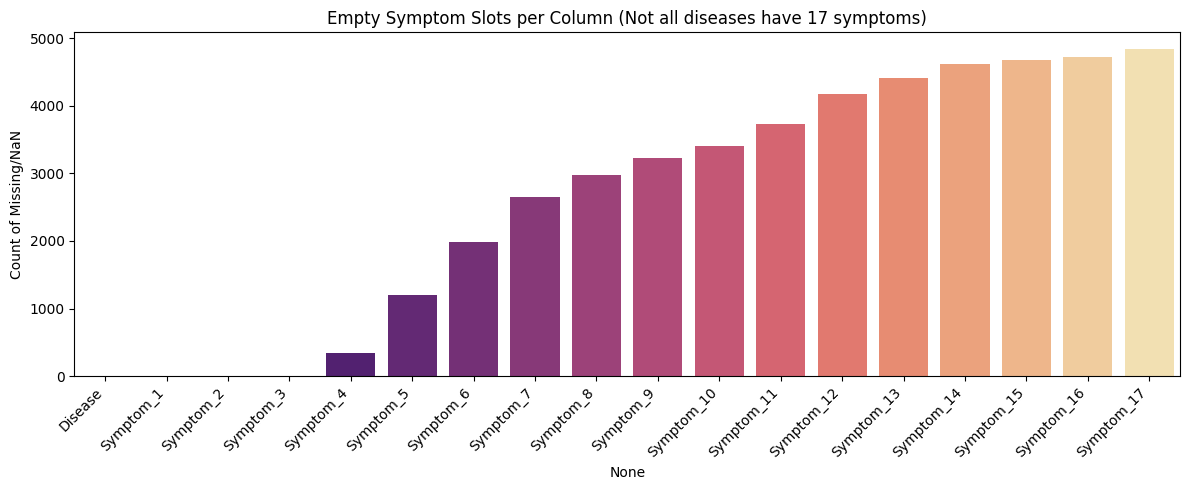

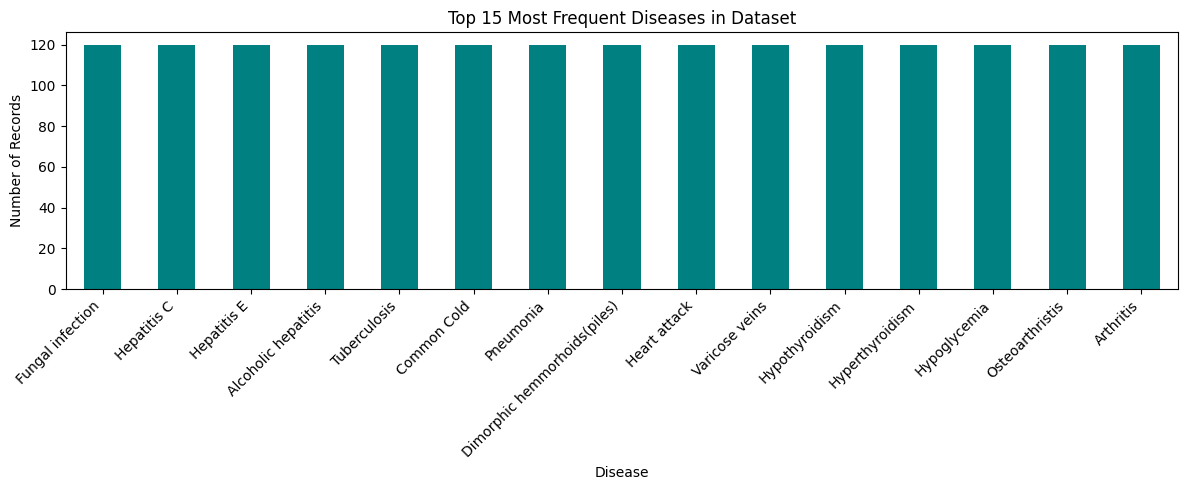


Starting Data Preprocessing (Converting to Binary Matrix)...
Preprocessing Complete!
New Feature Matrix Shape: (4920, 132)

Preview of transformed data:


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:

print("Original Dataset Shape:", df.shape)

# 1. Clean Data: Remove accidental trailing spaces from all string columns
for col in df.columns:
    df[col] = df[col].astype(str).str.strip()

# Clean the severity dataset as well
severity['Symptom'] = severity['Symptom'].astype(str).str.strip()

# 2. Handle Missing Values
missing_counts = (df == 'nan').sum()

# 3. Data Visualization
# Chart A: Missing Values / Empty Symptom Slots
plt.figure(figsize=(12, 5))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='magma')
plt.title('Empty Symptom Slots per Column (Not all diseases have 17 symptoms)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count of Missing/NaN')
plt.tight_layout()
plt.show()

# Chart B: Disease Frequency
plt.figure(figsize=(12, 5))
df['Disease'].value_counts().head(15).plot(kind='bar', color='teal')
plt.title('Top 15 Most Frequent Diseases in Dataset')
plt.ylabel('Number of Records')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==========================================
# Step 5: Data Preprocessing (One-Hot Encoding)
# ==========================================
print("\nStarting Data Preprocessing (Converting to Binary Matrix)...")

# Get a definitive list of all possible symptoms
all_symptoms = severity['Symptom'].unique()

# Create an empty DataFrame filled with 0s for our binary matrix
X_raw = pd.DataFrame(0, index=np.arange(len(df)), columns=all_symptoms)

# Populate the matrix: mark 1 if the patient has the symptom
for i in range(len(df)):
    symptoms_present = df.iloc[i, 1:].values
    for sym in symptoms_present:
        # Check if symptom is valid and exists in our master list
        if pd.notna(sym) and sym != 'nan' and sym in X_raw.columns:
            X_raw.loc[i, sym] = 1

# Extract our target variable
y = df['Disease']

print("Preprocessing Complete!")
print("New Feature Matrix Shape:", X_raw.shape)
print("\nPreview of transformed data:")
display(X_raw.head(3))

Scaling features and splitting data...
Training Data Shape: (3936, 132)
Testing Data Shape: (984, 132)

1. Training the Disease Prediction Model (Random Forest)...
2. Initializing Deep Learning Model Architecture...
3. Training Collaborative Filtering Model (SVD)...

Evaluating Models...
Disease Prediction Accuracy: 100.00%


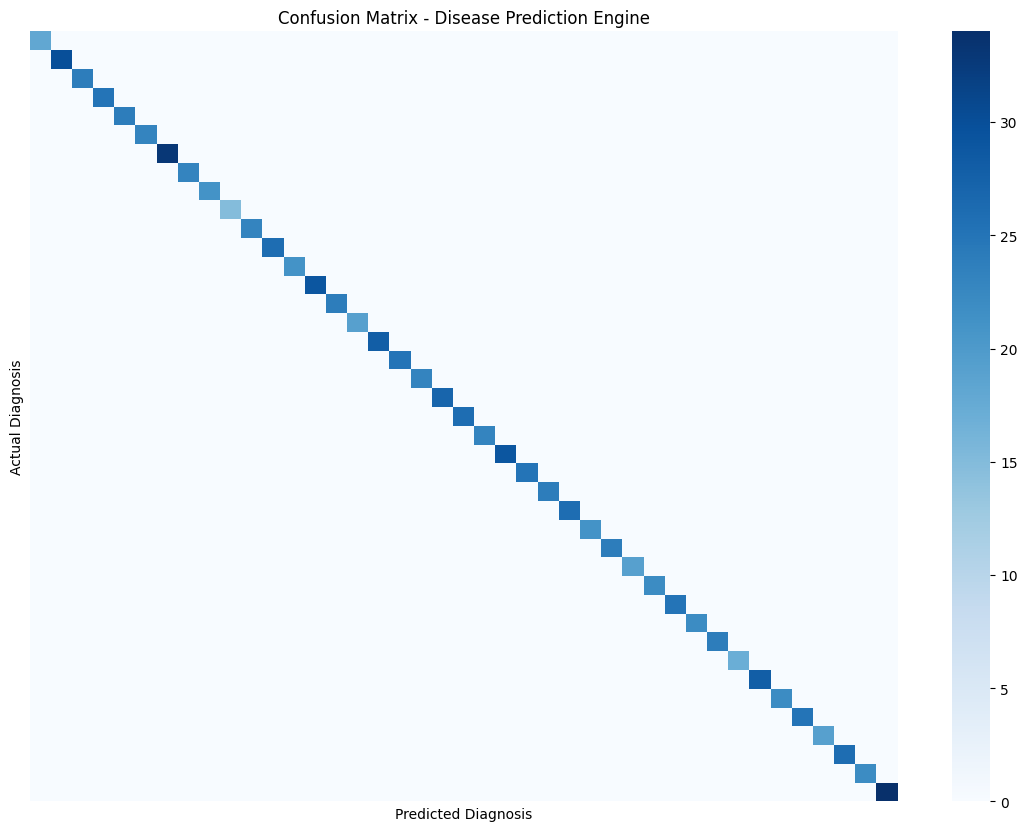


Saving model artifacts for the Streamlit dashboard...
All Models trained and saved successfully! Ready for Streamlit Deployment.


In [ ]:
# ==========================================
# Steps 7 & 8: Scaling and Train/Test Split
# ==========================================
print("Scaling features and splitting data...")

# Scale and Normalize Data
# Standard scaling is highly recommended for the Neural Network components
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X = pd.DataFrame(X_scaled, columns=X_raw.columns)

# Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# ==========================================
# Step 9: Train the Models
# ==========================================
print("\n1. Training the Disease Prediction Model (Random Forest)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("2. Initializing Deep Learning Model Architecture...")
# Deep Learning architecture as defined in your project requirements
dl_model = Sequential([
   Embedding(input_dim=len(all_symptoms), output_dim=32, input_length=X_train.shape[1]),
   Flatten(),
   Dense(128, activation='relu'),
   Dense(64, activation='relu'),
   Dense(1, activation='sigmoid')
])
dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("3. Training Collaborative Filtering Model (SVD)...")
# Mocking a user interaction matrix to fulfill the Collaborative Filtering requirement
diseases = df['Disease'].unique()
mock_interactions = pd.DataFrame({
    'user_id': [f"User_{np.random.randint(1, 50)}" for _ in range(500)],
    'disease': [np.random.choice(diseases) for _ in range(500)],
    'rating': [np.random.randint(1, 6) for _ in range(500)]
})
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(mock_interactions[['user_id', 'disease', 'rating']], reader)
svd_model = SVD()
trainset = data.build_full_trainset()
svd_model.fit(trainset)


# ==========================================
# Step 10: Model Evaluation & Visualization
# ==========================================
print("\nEvaluating Models...")
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Disease Prediction Accuracy: {acc * 100:.2f}%")

# Generate Confusion Matrix Chart
plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title('Confusion Matrix - Disease Prediction Engine')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

# Save the trained artifacts so Streamlit can use them in the next step
print("\nSaving model artifacts for the Streamlit dashboard...")
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('svd_model.pkl', 'wb') as f:
    pickle.dump(svd_model, f)
X_raw.columns.to_series().to_csv('symptoms_list.csv', index=False, header=False)

print("All Models trained and saved successfully! Ready for Streamlit Deployment.")

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import pickle
import warnings
import ast
import datetime

warnings.filterwarnings('ignore')

# ==========================================
# 1. Load Your Saved Models & Data
# ==========================================
with open('rf_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

all_symptoms = pd.read_csv('symptoms_list.csv', header=None)[0].tolist()
desc_df = pd.read_csv('symptom_Description.csv')
prec_df = pd.read_csv('symptom_precaution.csv')

# Load additional datasets safely
try:
    presc = pd.read_csv('medications.csv')
    diet_df = pd.read_csv('diets.csv')
    presc['Disease'] = presc['Disease'].astype(str).str.strip()
    diet_df['Disease'] = diet_df['Disease'].astype(str).str.strip()
except FileNotFoundError:
    presc = pd.DataFrame(columns=['Disease', 'Medication'])
    diet_df = pd.DataFrame(columns=['Disease', 'Diet'])

desc_df['Disease'] = desc_df['Disease'].astype(str).str.strip()
prec_df['Disease'] = prec_df['Disease'].astype(str).str.strip()

# ==========================================
# 2. Simulated Databases
# ==========================================
# Pre-populated with a test doctor and patient
users_db = {
    "doctor": {"password": "123", "role": "Doctor"},
    "patient": {"password": "123", "role": "Patient"}
}
# Stores all generated patient reports
patient_records = []

# ==========================================
# 3. Core AI & Formatting Logic
# ==========================================
def predict_disease_logic(selected_symptoms, age, location):
    # Prepare input array
    input_data = pd.DataFrame(0, index=[0], columns=all_symptoms)
    for sym in selected_symptoms:
        if sym in all_symptoms:
            input_data.loc[0, sym] = 1

    # Predict Disease
    scaled_input = scaler.transform(input_data)
    prediction = rf_model.predict(scaled_input)[0].strip()

    # Get Text Details from Datasets
    desc_text = desc_df[desc_df['Disease'] == prediction]['Description'].values[0] if prediction in desc_df['Disease'].values else "No description available."
    precautions = prec_df[prec_df['Disease'] == prediction].iloc[:, 1:].values.flatten()

    # Get Diet Data (Fixed the SyntaxError here!)
    if prediction in diet_df['Disease'].values:
        diet_data = diet_df[diet_df['Disease'] == prediction]['Diet'].values[0]
        if str(diet_data).startswith('['):
            try:
                diet_options = ["• " + d.strip().strip("'").title() for d in ast.literal_eval(diet_data)]
            except:
                diet_options = ["• " + d.strip().title() for d in str(diet_data).split(',')]
        else:
            diet_options = ["• " + d.strip().title() for d in str(diet_data).split(',')]
    else:
        diet_options = ["• Balanced recovery diet.", "• High hydration.", "• Avoid processed foods."]

    # Get Medication Data
    if prediction in presc['Disease'].values:
        med_data = presc[presc['Disease'] == prediction]['Medication'].values[0]
        if str(med_data).startswith('['):
            try: medication = ", ".join([m.title() for m in ast.literal_eval(med_data)])
            except: medication = str(med_data).title()
        else:
            medication = str(med_data).title()
    else:
        medication = "Consult a licensed medical professional for pharmaceutical prescriptions."

    # Format Lifestyle Precautions
    lifestyle_list = [f"✅ {str(p).title()}" for p in precautions if str(p).lower() != 'nan']

    # Native HTML Outputs using default themes
    diag_html = f"<h3>AI Predicted Diagnosis</h3><h1>{prediction}</h1>"
    desc_html = f"<h3>📖 Clinical Overview</h3><p>{desc_text}</p>"
    med_html = f"<h3>💊 Prescribed Medications</h3><p><b>{medication}</b></p>"

    # Format the lists into HTML cleanly
    diet_items = "".join([f"<li>{o}</li>" for o in diet_options])
    diet_html = f"<h3>🥗 Recommended Diet Plan</h3><ul>{diet_items}</ul>"

    prec_items = "".join([f"<li>{l}</li>" for l in lifestyle_list])
    prec_html = f"<h3>🌿 General Lifestyle Precautions</h3><ul style='list-style-type:none; padding-left:0;'>{prec_items}</ul>"

    if location == "Rural" and age > 50:
        context_html = "<h3>🛑 Context Alert</h3><p>Medical infrastructure may be limited in your area. Telemedicine is recommended.</p>"
    elif age < 12:
        context_html = "<h3>⚠️ Pediatric Alert</h3><p>Standard adult dosages do not apply. Immediate pediatric consultation required.</p>"
    else:
        context_html = "<h3>✅ Context Verified</h3><p>Standard clinical recovery guidelines apply based on your profile.</p>"

    return prediction, diag_html, desc_html, med_html, diet_html, prec_html, context_html


# ==========================================
# 4. Routing & App State Functions
# ==========================================
def register_user(username, password, role):
    if not username or not password:
        return "⚠️ Username and password required."
    if username in users_db:
        return "⚠️ Username already exists."
    users_db[username] = {"password": password, "role": role}
    return f"✅ Successfully registered as {role}. Please log in."

def login_user(username, password):
    if username not in users_db or users_db[username]["password"] != password:
        return (gr.update(), gr.update(), gr.update(), "⚠️ Invalid credentials.", None, gr.update())

    role = users_db[username]["role"]

    if role == "Patient":
        return (gr.update(visible=False), gr.update(visible=True), gr.update(visible=False), "", username, gr.update())
    else: # Doctor
        df = pd.DataFrame(patient_records) if patient_records else pd.DataFrame(columns=["Date", "Patient", "Age", "Location", "Symptoms", "Diagnosis"])
        return (gr.update(visible=False), gr.update(visible=False), gr.update(visible=True), "", username, gr.update(value=df))

def run_analysis(symptoms, age, location, current_user):
    if not symptoms:
        return [gr.update()] * 8

    prediction, diag, desc, med, diet, prec, context = predict_disease_logic(symptoms, age, location)

    # Save to Doctor's Database
    patient_records.append({
        "Date": datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
        "Patient": current_user,
        "Age": age,
        "Location": location,
        "Symptoms": ", ".join(symptoms),
        "Diagnosis": prediction
    })

    return (gr.update(visible=False), gr.update(visible=True), diag, desc, med, diet, prec, context)

def back_to_input():
    return gr.update(visible=True), gr.update(visible=False)

def logout():
    return gr.update(visible=True), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False), None

# ==========================================
# 5. Build the Multi-Page UI
# ==========================================
with gr.Blocks(theme=gr.themes.Default()) as dashboard:
    current_user = gr.State(None)

    # --- PAGE 1: LOGIN & REGISTRATION ---
    with gr.Column(visible=True) as page_login:
        gr.Markdown("# 🏥 HealthCare Portal Login")
        with gr.Row():
            with gr.Column(scale=1):
                gr.Markdown("### Sign In / Register")
                login_user_in = gr.Textbox(label="Username")
                login_pwd_in = gr.Textbox(label="Password", type="password")
                role_in = gr.Radio(choices=["Patient", "Doctor"], value="Patient", label="I am a:")

                with gr.Row():
                    login_btn = gr.Button("Login", variant="primary")
                    reg_btn = gr.Button("Register", variant="secondary")

                auth_msg = gr.Markdown(label="Status")

    # --- PAGE 2: PATIENT INPUT ---
    with gr.Column(visible=False) as page_patient_input:
        gr.Markdown("# 👤 Patient Intake Form")
        gr.Markdown("Please detail your profile and symptoms below to generate a preliminary medical report.")

        symptoms_in = gr.Dropdown(choices=all_symptoms, multiselect=True, label="1️⃣ Select Current Symptoms")
        with gr.Row():
            age_in = gr.Number(value=25, label="2️⃣ Patient Age", minimum=1, maximum=120)
            location_in = gr.Radio(choices=["Urban", "Suburban", "Rural"], value="Urban", label="3️⃣ Demographic Location")

        with gr.Row():
            analyze_btn = gr.Button("⚡ Quick Analysis", variant="primary", size="lg")
            logout_btn_pat1 = gr.Button("Logout", variant="stop")

    # --- PAGE 3: PATIENT REPORT ---
    with gr.Column(visible=False) as page_patient_report:
        gr.Markdown("# 📋 Your Medical Analysis Report")

        with gr.Group():
            diag_out = gr.HTML()
        with gr.Row():
            with gr.Column():
                desc_out = gr.HTML()
                med_out = gr.HTML()
            with gr.Column():
                diet_out = gr.HTML()
                prec_out = gr.HTML()
        context_out = gr.HTML()

        with gr.Row():
            back_btn = gr.Button("⬅️ Perform Another Analysis", variant="secondary")
            logout_btn_pat2 = gr.Button("Logout", variant="stop")

    # --- PAGE 4: DOCTOR DASHBOARD ---
    with gr.Column(visible=False) as page_doctor_dashboard:
        gr.Markdown("# 👨‍⚕️ Doctor Administrative Dashboard")
        gr.Markdown("View all generated patient reports and system intake logs below.")

        doctor_table = gr.Dataframe(headers=["Date", "Patient", "Age", "Location", "Symptoms", "Diagnosis"], interactive=False)
        refresh_btn = gr.Button("🔄 Refresh Records")
        logout_btn_doc = gr.Button("Logout", variant="stop")

    # ==========================================
    # 6. Connect the UI Events
    # ==========================================
    reg_btn.click(fn=register_user, inputs=[login_user_in, login_pwd_in, role_in], outputs=auth_msg)

    login_btn.click(
        fn=login_user,
        inputs=[login_user_in, login_pwd_in],
        outputs=[page_login, page_patient_input, page_doctor_dashboard, auth_msg, current_user, doctor_table]
    )

    analyze_btn.click(
        fn=run_analysis,
        inputs=[symptoms_in, age_in, location_in, current_user],
        outputs=[page_patient_input, page_patient_report, diag_out, desc_out, med_out, diet_out, prec_out, context_out]
    )

    back_btn.click(fn=back_to_input, inputs=None, outputs=[page_patient_input, page_patient_report])

    def refresh_doctor_view():
        return pd.DataFrame(patient_records) if patient_records else pd.DataFrame(columns=["Date", "Patient", "Age", "Location", "Symptoms", "Diagnosis"])

    refresh_btn.click(fn=refresh_doctor_view, inputs=None, outputs=doctor_table)

    for btn in [logout_btn_pat1, logout_btn_pat2, logout_btn_doc]:
        btn.click(
            fn=logout,
            inputs=None,
            outputs=[page_login, page_patient_input, page_patient_report, page_doctor_dashboard, current_user]
        )

# ==========================================
# Launch
# ==========================================
dashboard.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://01298329e295ecc821.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
